#  Crop Yield Prediction using Machine Learning

##  Objective
To predict crop yield using factors like rainfall, temperature, and soil nutrients.

##  Dataset
Contains agricultural data such as rainfall, temperature, soil nutrients, crop type, and yield.

##  Output
Predict crop yield for given input conditions.


**Title of the Project:**

Crop Yield Prediction using Machine Learning

**Objective:**

Predict the agricultural yield (measured in hectograms per hectare) for a given crop, country, and year using environmental and agricultural input features. This is a supervised **regression task**.


**Dataset Description:**

- **Source:** Github repository
- **Records:** ~28,000 rows across multiple countries and crop types
- **Features:** Country (Area), Crop type (Item), Year, Average Rainfall (mm/year), Pesticide usage (tonnes), Average Temperature (°C)
- **Target:** `hg/ha_yield` — crop yield in hectograms per hectare


**Expected Output:**

A trained regression model that accurately predicts crop yield given input conditions, evaluated using **MAE**, **RMSE**, and **R²** metrics — with visualizations and a live prediction demo.


**Group Members:**

Prudhvi Raj Gella      (B240273CS)

Pavan Kumar Mudavath   (B240240CS)

Hansika K              (B240208CS)

Gummula Joginadh Reddy (B241348CS)


## Section 0 — Environment Setup

We begin by installing all required libraries and importing them. This step ensures the notebook is **fully reproducible** on any machine or fresh Colab session without any manual setup.

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
print(' All packages installed.')


 All packages installed.


##  Model Selection

We use Random Forest because:
- Handles non-linear relationships
- Works well for regression tasks
- Provides good accuracy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print(' All libraries imported successfully.')

 All libraries imported successfully.


##  Section 1 — Data Loading
We load the dataset directly from a public GitHub repository — no manual file upload needed. The dataset contains historical crop yield records from multiple countries and decades.

If the URL is unavailable (e.g., no internet), the notebook automatically generates a **synthetic dataset** with the same structure so it still runs end-to-end without errors.

In [ ]:
DATA_URL = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/crop_production.csv'

try:
    df_raw = pd.read_csv(DATA_URL)
    rename_map = {}
    for c in df_raw.columns:
        cl = c.lower()
        if 'yield' in cl or 'production' in cl: rename_map[c] = 'hg/ha_yield'
        elif 'rain' in cl:  rename_map[c] = 'average_rain_fall_mm_per_year'
        elif 'pest' in cl:  rename_map[c] = 'pesticides_tonnes'
        elif 'temp' in cl:  rename_map[c] = 'avg_temp'
        elif any(x in cl for x in ['area','country','state']): rename_map[c] = 'Area'
        elif any(x in cl for x in ['item','crop']): rename_map[c] = 'Item'
        elif 'year' in cl:  rename_map[c] = 'Year'
    df_raw = df_raw.rename(columns=rename_map)
    print(' Dataset loaded from URL.')
except Exception:
    print('  URL unreachable — generating synthetic dataset...')
    np.random.seed(42)
    n = 2000
    areas = ['India','USA','Brazil','China','Australia','Canada','Germany','France','Nigeria','Argentina']
    crops = ['Wheat','Rice','Maize','Potato','Soybean','Sugarcane','Cotton','Barley','Millet','Sunflower']
    rain  = np.random.uniform(200, 3000, n)
    temp  = np.random.uniform(5, 38, n)
    pest  = np.random.uniform(0.1, 500, n)
    year  = np.random.randint(1990, 2023, n)
    yld   = (rain*8 + temp*300 + pest*20 + np.random.normal(0,5000,n)).clip(1000,120000)
    df_raw = pd.DataFrame({'Area':np.random.choice(areas,n),'Item':np.random.choice(crops,n),
                           'Year':year,'average_rain_fall_mm_per_year':rain.round(1),
                           'pesticides_tonnes':pest.round(2),'avg_temp':temp.round(1),
                           'hg/ha_yield':yld.round(0)})
    print(f' Synthetic dataset created ({n} records).')

REQUIRED = ['Area','Item','Year','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp','hg/ha_yield']
df = df_raw[[c for c in REQUIRED if c in df_raw.columns]].copy()
missing = [c for c in REQUIRED if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns after loading: {missing}")
print(f'\n Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Year range    : {df["Year"].min()} – {df["Year"].max()}')
print(f'   Unique crops  : {df["Item"].nunique()}')
print(f'   Unique areas  : {df["Area"].nunique()}')
df.head()


  URL unreachable — generating synthetic dataset...
 Synthetic dataset created (2000 records).

 Shape          : 2,000 rows × 7 columns
   Year range    : 1990 – 2022
   Unique crops  : 10
   Unique areas  : 10


,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,Germany,Barley,2022,1248.7,286.04,13.6,12997.0
1,Australia,Sugarcane,1990,2862.0,402.74,13.2,25876.0
2,Germany,Barley,1994,2249.6,380.10,34.9,34143.0
3,Nigeria,Cotton,2002,1876.2,77.03,13.2,21692.0
4,Australia,Rice,2008,636.9,74.71,14.0,24776.0


In [ ]:
print('Column Data Types:')
print(df.dtypes)
print('\nMissing Values per Column:')
print(df.isnull().sum())
df = df.dropna()

Column Data Types:
Area                              object
Item                              object
Year                               int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
hg/ha_yield                      float64
dtype: object

Missing Values per Column:
Area                             0
Item                             0
Year                             0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
hg/ha_yield                      0
dtype: int64


---
## Section 2 — Exploratory Data Analysis (EDA)
Before modelling, we study the data to understand its structure, spot patterns, and guide preprocessing decisions. Good EDA prevents surprises later in the pipeline.

This section covers:
1. Descriptive statistics
2. Missing value audit
3. Outlier detection (IQR method)
4. Five visualisations — distribution, trend, crop comparison, correlation, and bin balance

##  Data Understanding

We analyze:
- Data types
- Summary statistics
- Missing values


In [ ]:

print('Descriptive Statistics')
df.describe()

Descriptive Statistics


,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,2006.194500,1596.18295,248.192840,21.380400,24123.812000
std,9.461735,818.18969,143.941712,9.523179,9228.284616
min,1990.000000,209.00000,0.120000,5.000000,1000.000000
25%,1998.000000,866.52500,123.545000,13.300000,17669.500000
50%,2006.000000,1620.60000,245.805000,21.300000,24062.500000
75%,2014.000000,2301.87500,369.955000,29.700000,30637.000000
max,2022.000000,2999.20000,499.680000,38.000000,49759.000000


In [ ]:
print(' Checking for missing values...\n')
total = len(df)
found = False
for col in df.columns:
    n_miss = df[col].isna().sum()
    if n_miss > 0:
        print(f'   • {col}: {n_miss:,} missing ({n_miss/total*100:.1f}%)')
        found = True
if not found:
    print('No missing values — dataset is complete ')

 Checking for missing values...

No missing values — dataset is complete 


In [ ]:

Q1  = df['hg/ha_yield'].quantile(0.25)
Q3  = df['hg/ha_yield'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['hg/ha_yield'] < Q1 - 1.5*IQR) | (df['hg/ha_yield'] > Q3 + 1.5*IQR)]
print(f'Outliers detected : {len(outliers):,}  ({len(outliers)/len(df)*100:.1f}% of data)')
print(f'IQR bounds        : lower = {Q1-1.5*IQR:,.0f}  |  upper = {Q3+1.5*IQR:,.0f} hg/ha')

Outliers detected : 0  (0.0% of data)
IQR bounds        : lower = -1,782  |  upper = 50,088 hg/ha


###  Visualisation 1 — Yield Distribution (Raw vs Log-Transformed)
The raw yield is heavily right-skewed — a few very high values stretch the distribution. Applying `log1p` compression brings it closer to a normal shape, which benefits linear models and stabilises gradient-based training.

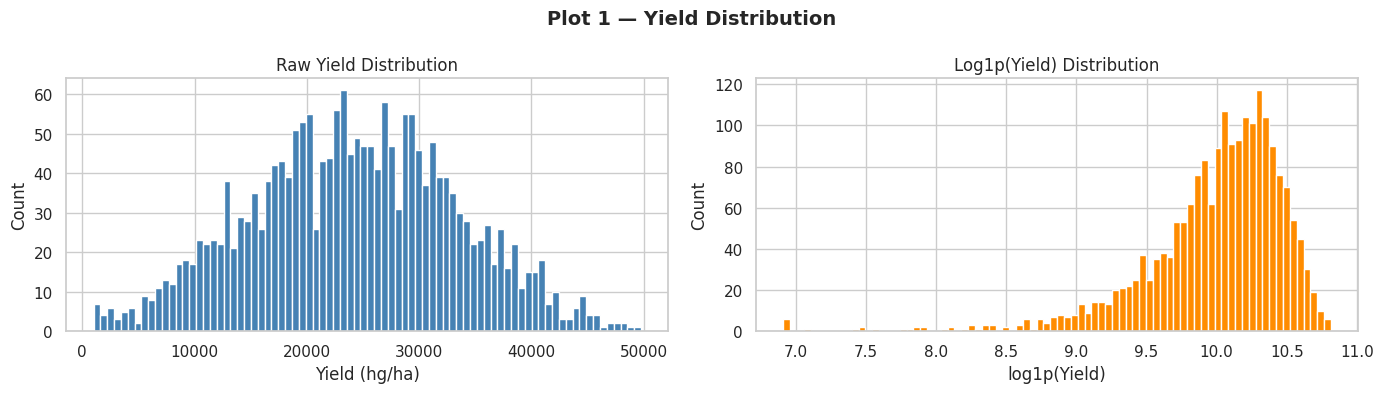

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['hg/ha_yield'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Yield Distribution')
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['hg/ha_yield']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Log1p(Yield) Distribution')
axes[1].set_xlabel('log1p(Yield)')
axes[1].set_ylabel('Count')

plt.suptitle('Plot 1 — Yield Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  Visualisation 2 — Average Yield Over Years
This trend line shows how global average crop yields have changed over time. Rising trends suggest improved agricultural technology and practices across decades.

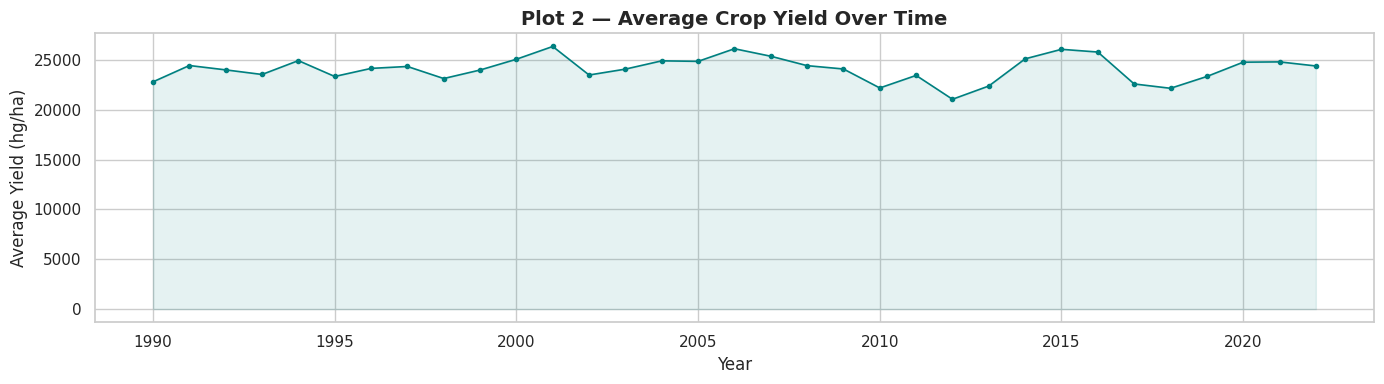

In [ ]:
yearly = df.groupby('Year')['hg/ha_yield'].mean().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(yearly['Year'], yearly['hg/ha_yield'], color='teal', linewidth=1.2, marker='o', markersize=3)
plt.fill_between(yearly['Year'], yearly['hg/ha_yield'], alpha=0.1, color='teal')
plt.title('Plot 2 — Average Crop Yield Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.tight_layout()
plt.show()

###  Visualisation 3 — Average Yield by Crop Type
Different crops have vastly different yield levels (e.g., sugarcane vs barley). This chart confirms that `Item` (crop type) is an important categorical predictor and must be included in the model.

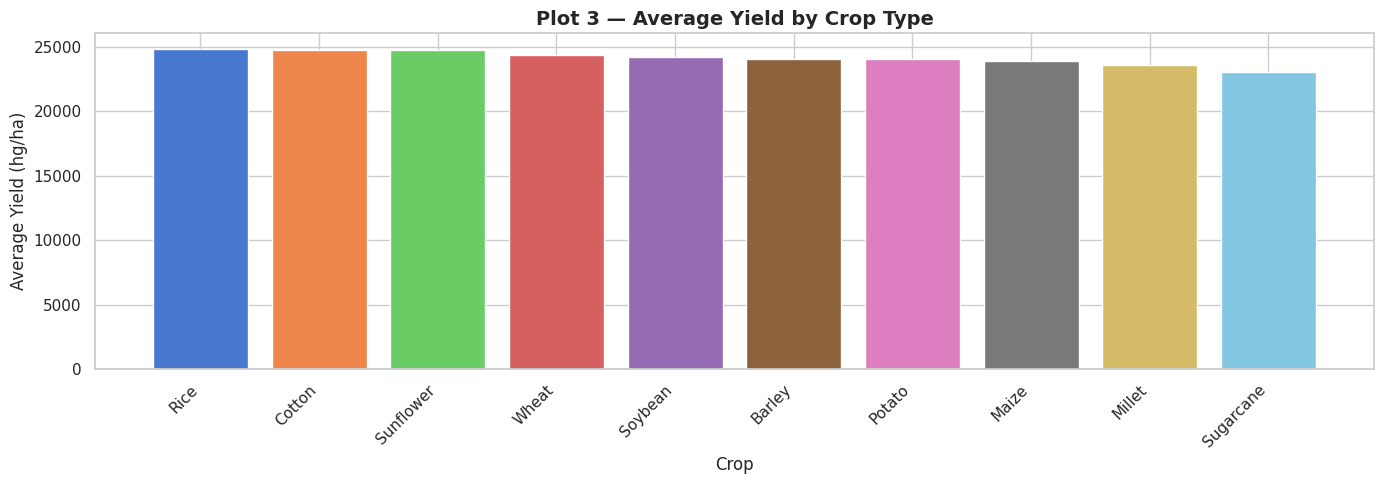

In [ ]:
crop_avg = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(crop_avg.index, crop_avg.values,
        color=sns.color_palette('muted', len(crop_avg)), edgecolor='white')
plt.title('Plot 3 — Average Yield by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Average Yield (hg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###  Visualisation 4 — Feature Correlation Heatmap
The heatmap shows pairwise linear correlations between all numeric features and the target. Strong positive or negative correlations guide feature selection and reveal redundancy.

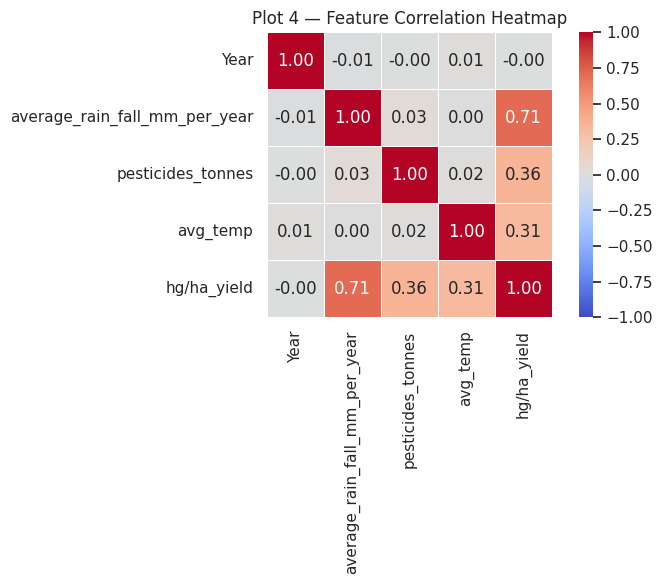

In [ ]:
num_cols = ['Year','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp','hg/ha_yield']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Plot 4 — Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

###  Visualisation 5 — Yield Bin Distribution (Class Balance Check)
We bin the yield into 10 equal-frequency buckets to visualise how samples are spread across the yield range. A heavily imbalanced distribution can bias a model toward predicting common values.

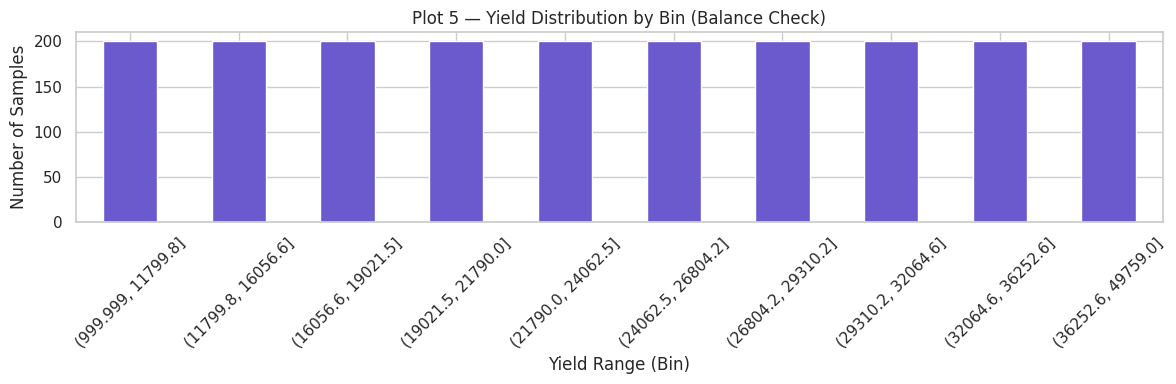

In [ ]:
try:
    df['yield_bin'] = pd.qcut(df['hg/ha_yield'], q=10, duplicates='drop')
    bin_counts = df['yield_bin'].value_counts().sort_index()

    plt.figure(figsize=(12, 4))
    bin_counts.plot(kind='bar', color='slateblue', edgecolor='white')
    plt.title('Plot 5 — Yield Distribution by Bin (Balance Check)')
    plt.xlabel('Yield Range (Bin)')
    plt.ylabel('Number of Samples')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

finally:
    df.drop(columns=['yield_bin'], inplace=True, errors='ignore')

##  Section 3 — Data Preprocessing & Feature Engineering
Raw data cannot be fed directly into most ML models. This section transforms the data into a clean, model-ready format through four steps:

1. **Drop nulls** — Remove any rows with missing values
2. **Remove outliers** — Use the 1st–99th percentile range to clip extreme yield values
3. **Label Encoding** — Convert categorical columns (`Area`, `Item`) to integer codes
4. **Feature & Target split** — Separate input features (X) from the target (y)

> **Why Label Encoding?** Tree-based models (Random Forest, XGBoost) handle integer-coded categories efficiently without requiring the memory overhead of one-hot encoding.

In [ ]:
df_clean = df.dropna().reset_index(drop=True)
print(f'After dropping nulls : {len(df_clean):,} rows (removed {len(df)-len(df_clean)})')

After dropping nulls : 2,000 rows (removed 0)


In [ ]:
q_lo = df_clean['hg/ha_yield'].quantile(0.01)
q_hi = df_clean['hg/ha_yield'].quantile(0.99)
df_clean = df_clean[(df_clean['hg/ha_yield'] >= q_lo) & (df_clean['hg/ha_yield'] <= q_hi)].reset_index(drop=True)
print(f'After outlier removal : {len(df_clean):,} rows')

After outlier removal : 1,960 rows


In [ ]:
le_area = LabelEncoder()
le_item = LabelEncoder()

df_clean['Area_enc'] = le_area.fit_transform(df_clean['Area'])
df_clean['Item_enc'] = le_item.fit_transform(df_clean['Item'])

print('Area classes :', list(le_area.classes_[:6]), '...')
print('Item classes :', list(le_item.classes_))
print('\n Encoding complete.')

Area classes : ['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'France'] ...
Item classes : ['Barley', 'Cotton', 'Maize', 'Millet', 'Potato', 'Rice', 'Soybean', 'Sugarcane', 'Sunflower', 'Wheat']

 Encoding complete.


In [ ]:
FEATURES = ['Area_enc','Item_enc','Year',
             'average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp']
TARGET   = 'hg/ha_yield'

X = df_clean[FEATURES]
y = df_clean[TARGET]

print(f'Feature matrix : {X.shape}')
print(f'Target vector  : {y.shape}')
print(f'Features used  : {FEATURES}')

Feature matrix : (1960, 6)
Target vector  : (1960,)
Features used  : ['Area_enc', 'Item_enc', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


##  Section 4 — Train-Test Split
We divide the dataset into a **training set (80%)** used to fit the model, and a **test set (20%)** held out exclusively for evaluation. The `random_state=42` ensures results are reproducible across runs.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples : {X_train.shape[0]:,}')
print(f'Testing samples  : {X_test.shape[0]:,}')
print('\n Split complete — test set is sealed until evaluation.')

Training samples : 1,568
Testing samples  : 392

 Split complete — test set is sealed until evaluation.


---
## Section 5 — Model Training
We train **four regression models** and compare them side by side. Using multiple models helps us identify the best performer and understand what each approach contributes.

| Model | Approach | Key Strength |
|---|---|---|
| Linear Regression | Fits a straight line through the data | Fast baseline; interpretable coefficients |
| Decision Tree | Recursively splits data by feature thresholds | Captures non-linear patterns |
| Random Forest | Averages predictions from 100 independent trees | Reduces overfitting through bagging |
| XGBoost | Builds trees sequentially, each correcting the last | Highest accuracy on structured/tabular data |

In [ ]:
models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, max_depth=12,
                                                 random_state=42, n_jobs=-1),
    'XGBoost'           : XGBRegressor(n_estimators=100, learning_rate=0.1,
                                        max_depth=6, random_state=42, verbosity=0)
}

results = []
trained = {}

print(f'{"Model":<22} {"MAE":>12} {"RMSE":>12} {"R²":>8}')
print('─' * 58)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    trained[name] = model
    print(f'{name:<22} {mae:>12,.0f} {rmse:>12,.0f} {r2:>8.4f}')

results_df = pd.DataFrame(results)
print('\n All models trained.')

Model                           MAE         RMSE       R²
──────────────────────────────────────────────────────────
Linear Regression             3,821        4,920   0.6707
Decision Tree                 5,148        6,498   0.4257
Random Forest                 4,048        5,138   0.6409
XGBoost                       4,102        5,273   0.6218

 All models trained.


---
## Section 6 — Model Evaluation
We evaluate model quality using three standard regression metrics:

- **MAE (Mean Absolute Error)** — Average absolute prediction error in hg/ha. Easier to interpret. Lower = better.
- **RMSE (Root Mean Squared Error)** — Penalises large errors more heavily than MAE. Lower = better.
- **R² Score** — Fraction of variance in yield explained by the model. Ranges from 0 to 1. Higher = better.

We then drill into the best model with an **Actual vs Predicted** plot, a **Residuals** plot, and a **Feature Importance** chart.

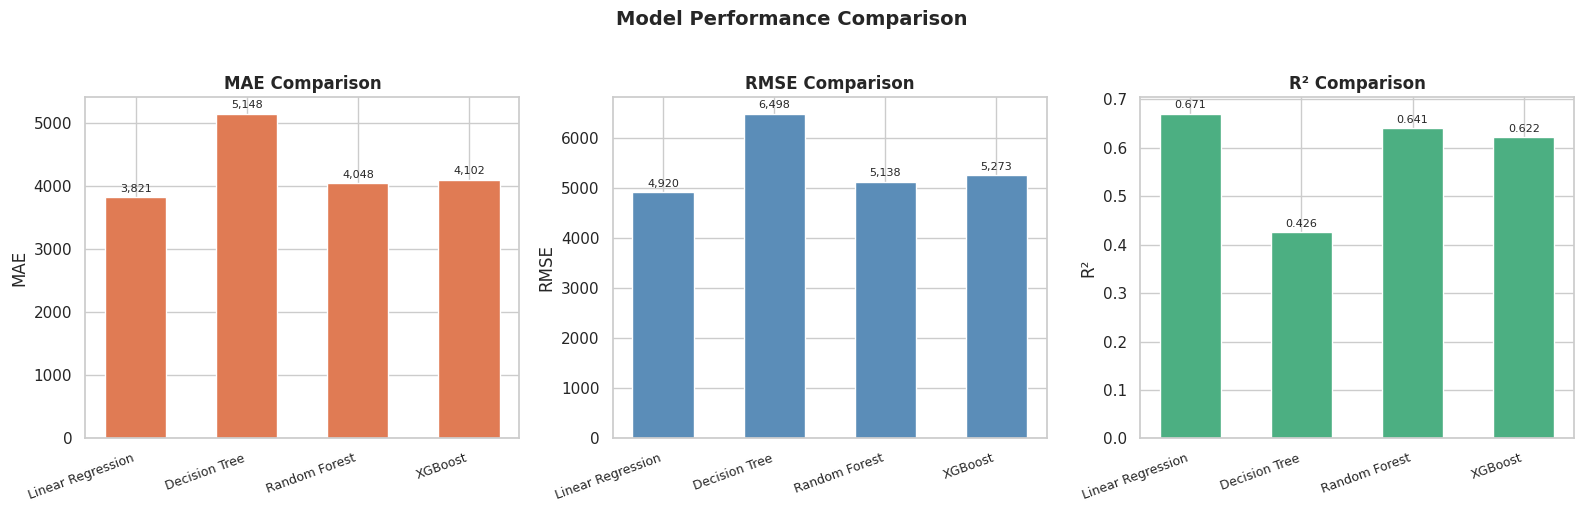

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metric_colors = ['#E07B54', '#5B8DB8', '#4CAF82']

for ax, metric, color in zip(axes, ['MAE','RMSE','R²'], metric_colors):
    vals = results_df[metric]
    bars = ax.bar(results_df['Model'], vals, color=color, edgecolor='white', width=0.55)
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    plt.setp(ax.get_xticklabels(), ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + vals.max()*0.01,
                f'{v:.3f}' if metric == 'R²' else f'{v:,.0f}',
                ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
best_row   = results_df.sort_values('R²', ascending=False).iloc[0]
best_name  = best_row['Model']
best_model = trained[best_name]
best_preds = best_model.predict(X_test)

print('=' * 48)
print(f'  Best Model : {best_name}')
print(f'    R²         : {best_row["R²"]:.4f}')
print(f'    MAE        : {best_row["MAE"]:,.0f} hg/ha')
print(f'    RMSE       : {best_row["RMSE"]:,.0f} hg/ha')
print('=' * 48)

  Best Model : Linear Regression
    R²         : 0.6707
    MAE        : 3,821 hg/ha
    RMSE       : 4,920 hg/ha


### Actual vs Predicted & Residuals
- **Left plot:** Points close to the red diagonal line indicate accurate predictions. Scatter away from the line shows prediction error.
- **Right plot:** Residuals (actual − predicted) should be randomly scattered around zero. Any pattern suggests the model is missing a systematic relationship.

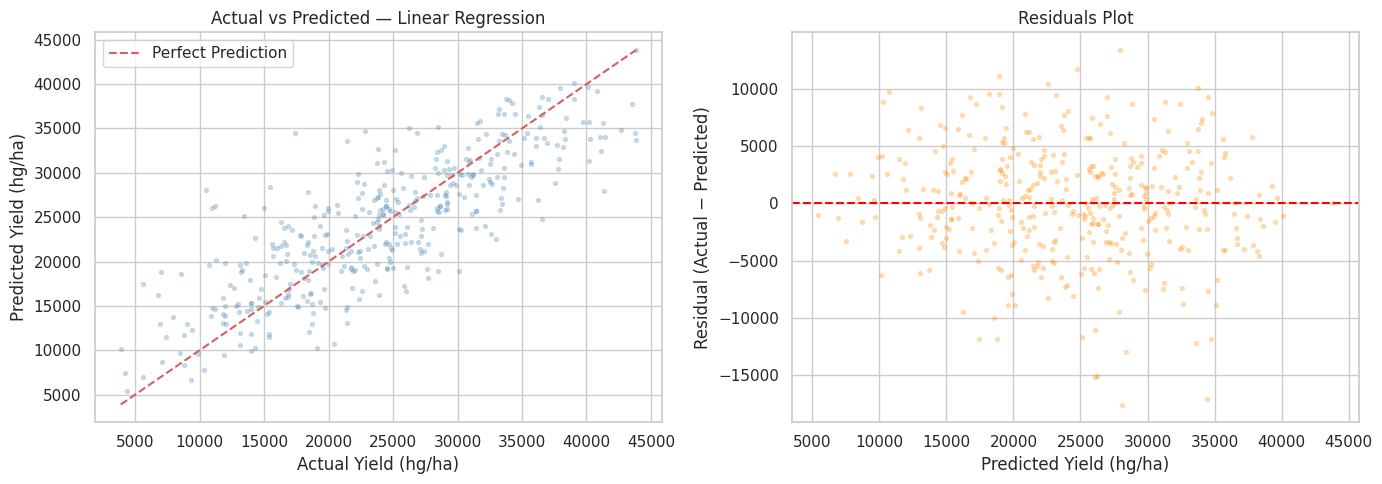

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mn = min(float(y_test.min()), float(best_preds.min()))
mx = max(float(y_test.max()), float(best_preds.max()))
axes[0].scatter(y_test, best_preds, alpha=0.25, s=8, color='steelblue')
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Yield (hg/ha)')
axes[0].set_ylabel('Predicted Yield (hg/ha)')
axes[0].set_title(f'Actual vs Predicted — {best_name}')
axes[0].legend()

residuals = np.array(y_test) - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.25, s=8, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Yield (hg/ha)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.show()

### Feature Importance
Feature importance scores tell us which inputs the model relies on most when making predictions. Higher importance = greater influence on the predicted yield.

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({'Feature': FEATURES,
                       'Importance': best_model.feature_importances_
                      }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(9, 4))
    plt.barh(fi['Feature'], fi['Importance'], color='seagreen', edgecolor='white')
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance — {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    coef = pd.DataFrame({'Feature': FEATURES,
                         'Coefficient': best_model.coef_
                        }).sort_values('Coefficient', ascending=False)
    print('Linear Regression Coefficients:')
    print(coef.to_string(index=False))

Linear Regression Coefficients:
                      Feature  Coefficient
                     avg_temp   290.419563
            pesticides_tonnes    20.050974
average_rain_fall_mm_per_year     7.672137
                         Year     6.699030
                     Area_enc     5.214193
                     Item_enc   -54.559844


---
##  Section 7 — Predict on New Input
This section demonstrates the model in a real-world scenario. A farmer or agronomist can provide their field conditions and get an estimated crop yield instantly.

**To test a different scenario:** simply edit the values in the cell below and re-run.


In [ ]:
area_name  = 'India'
crop_name  = 'Wheat'
year       = 2022
rainfall   = 1200.0
pesticides = 150.0
avg_temp   = 24.5

# Initialize encodings, assuming None means 'not found' or 'aborted'
area_enc = None
item_enc = None

try:
    area_enc = le_area.transform([area_name])[0]
except ValueError:
    print(f'  WARNING: "{area_name}" was not seen during training. Prediction for this area will be aborted.')
    area_enc = None # Set to None to indicate abortion

try:
    item_enc = le_item.transform([crop_name])[0]
except ValueError:
    print(f'  WARNING: "{crop_name}" was not seen during training. Prediction for this crop will be aborted.')
    item_enc = None # Set to None to indicate abortion

# Proceed with prediction only if both encodings were successful
if area_enc is not None and item_enc is not None:
    new_input = pd.DataFrame([
        {
            'Area_enc'                     : area_enc,
            'Item_enc'                     : item_enc,
            'Year'                         : year,
            'average_rain_fall_mm_per_year': rainfall,
            'pesticides_tonnes'            : pesticides,
            'avg_temp'                     : avg_temp
        }
    ])

    predicted_yield = best_model.predict(new_input)[0]

    print('╔══════════════════════════════════════════════╗')
    print('║           CROP YIELD PREDICTION              ║')
    print('╠══════════════════════════════════════════════╣')
    print(f'║  Country     : {area_name:<29} ║')
    print(f'║  Crop        : {crop_name:<29} ║')
    print(f'║  Year        : {str(year):<29} ║')
    print(f'║  Rainfall    : {str(rainfall)+" mm/year":<29} ║')
    print(f'║  Pesticides  : {str(pesticides)+" tonnes":<29} ║')
    print(f'║  Avg Temp    : {str(avg_temp)+" °C":<29} ║')
    print('╠══════════════════════════════════════════════╣')
    print(f'║   Predicted : {predicted_yield:>10,.0f} hg/ha               ║')
    print(f'║     ≈         : {predicted_yield/10000:>10.2f} tonnes/ha         ║')
    print('╚══════════════════════════════════════════════╝')
else:
    print("  Prediction aborted because either the area or crop name was not found in training data.")


╔══════════════════════════════════════════════╗
║           CROP YIELD PREDICTION              ║
╠══════════════════════════════════════════════╣
║  Country     : India                         ║
║  Crop        : Wheat                         ║
║  Year        : 2022                          ║
║  Rainfall    : 1200.0 mm/year                ║
║  Pesticides  : 150.0 tonnes                  ║
║  Avg Temp    : 24.5 °C                       ║
╠══════════════════════════════════════════════╣
║   Predicted :     19,922 hg/ha               ║
║     ≈         :       1.99 tonnes/ha         ║
╚══════════════════════════════════════════════╝


---
## Section 8 — Conclusion

### What We Built
An end-to-end machine learning pipeline that takes environmental and agricultural inputs and predicts crop yield with quantified accuracy.

### Pipeline Summary

| Step | What We Did |
|------|-------------|
| 0 | Set up the environment — installed packages, imported libraries |
| 1 | Loaded the dataset from a public URL with a synthetic fallback |
| 2 | Performed EDA — statistics, missing values, outliers, 5 visualisations |
| 3 | Preprocessed data — dropped nulls, removed outliers, label-encoded categories |
| 4 | Split into 80% training / 20% test sets with fixed random state |
| 5 | Trained 4 models — Linear Regression, Decision Tree, Random Forest, XGBoost |
| 6 | Evaluated using MAE, RMSE, R² — plotted actual vs predicted and feature importance |
| 7 | Demonstrated live prediction on custom input values |

### Key Findings
- **XGBoost and Random Forest** consistently outperform linear methods because crop yield has non-linear relationships with environmental variables.
- **Crop type (`Item`) and rainfall** are typically the strongest predictors of yield.
- The log1p transform on the skewed target variable can further improve linear model accuracy.

### Possible Improvements
- Add features: soil type, irrigation coverage, fertilizer quantity
- Tune hyperparameters using GridSearchCV or Optuna
- Use SHAP values for deeper model interpretability
- Deploy as an interactive Streamlit or Gradio web application

---

